In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from catboost import CatBoostRegressor
from neuralforecast import NeuralForecast
from neuralforecast.models import DeepAR, NBEATS, TCN

In [124]:
SUN_PATH = 'sunspots.csv'
POLLUTION_PATH = 'PRSA.csv'

df_sun = pd.read_csv(SUN_PATH)
df_sun['Month'] = pd.to_datetime(df_sun['Month'])
df_sun = df_sun.set_index('Month').asfreq(freq='MS').reset_index()
df_sun['Sunspots'] = df_sun['Sunspots'].interpolate(method='linear')
bounds = np.percentile(df_sun['Sunspots'].dropna(), [1, 99])
df_sun['sunspots_clipped'] = df_sun['Sunspots'].clip(lower=bounds[0], upper=bounds[1])
print(f"Солнечная активность: {len(df_sun)} записей")

Солнечная активность: 2820 записей


In [125]:
df_pollution = pd.read_csv(POLLUTION_PATH)
df_pollution['datetime'] = pd.to_datetime(df_pollution[['year', 'month', 'day', 'hour']])
df_pollution = df_pollution.sort_values('datetime').reset_index(drop=True)

target_col = 'PM2.5'
raw_exog = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']

for col in raw_exog + [target_col]:
    df_pollution[col].fillna(df_pollution[col].median(), inplace=True)

df_pollution['hour_sin'] = np.sin(2 * np.pi * df_pollution['hour'] / 24)
df_pollution['hour_cos'] = np.cos(2 * np.pi * df_pollution['hour'] / 24)
df_pollution['month_sin'] = np.sin(2 * np.pi * df_pollution['month'] / 12)
df_pollution['month_cos'] = np.cos(2 * np.pi * df_pollution['month'] / 12)
df_pollution['dayofweek'] = df_pollution['datetime'].dt.dayofweek

futr_exog_pol = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofweek']
exog_cols = raw_exog + futr_exog_pol
print(f"Beijing Pollution: {len(df_pollution)} записей, признаков: {len(exog_cols)}")

Beijing Pollution: 35064 записей, признаков: 14


In [126]:
train_sun, test_sun = train_test_split(df_sun, test_size=0.2, shuffle=False)
print(f"Солнце: train={len(train_sun)}, test={len(test_sun)}")

df_pollution_hourly = df_pollution.iloc[::6, :].reset_index(drop=True)
train_pollution, test_pollution = train_test_split(df_pollution_hourly, test_size=0.2, shuffle=False)
print(f"Pollution: train={len(train_pollution)}, test={len(test_pollution)}")

Солнце: train=2256, test=564
Pollution: train=4675, test=1169


In [127]:
def create_features(df_train, df_test, target_col, exog_cols, max_lag=12, seasonal_period=24):
    df_all = pd.concat([df_train.copy(), df_test.copy()], ignore_index=True)
    n_train = len(df_train)

    for lag in [1, 2, 3, 6, max_lag]:
        df_all[f'lag_{lag}_{target_col}'] = df_all[target_col].shift(lag)
    for lag in [seasonal_period, seasonal_period * 2]:
        df_all[f'seasonal_lag_{lag}_{target_col}'] = df_all[target_col].shift(lag)
    for diff in [1, 2]:
        df_all[f'diff_{diff}_{target_col}'] = df_all[target_col].diff(diff)
    df_all[f'seasonal_diff_{seasonal_period}_{target_col}'] = df_all[target_col].diff(seasonal_period)

    for window in [3, 6, 12]:
        df_all[f'rolling_mean_{window}_{target_col}'] = df_all[target_col].rolling(window).mean()
        df_all[f'rolling_std_{window}_{target_col}'] = df_all[target_col].rolling(window).std()

    for exog in exog_cols[:5]:
        for lag in [1, 3, 6]:
            df_all[f'lag_{lag}_{exog}'] = df_all[exog].shift(lag)
        for window in [3, 6]:
            df_all[f'rolling_mean_{window}_{exog}'] = df_all[exog].rolling(window).mean()

    return df_all.iloc[:n_train].copy(), df_all.iloc[n_train:].copy()

In [128]:
df_sun_train, df_sun_test = create_features(train_sun, test_sun, 'sunspots_clipped', [], 12, 12)
df_pollution_train, df_pollution_test = create_features(
    train_pollution, test_pollution, target_col, exog_cols, 24, 24)

df_sun_train = df_sun_train.dropna().reset_index(drop=True)
df_sun_test = df_sun_test.dropna().reset_index(drop=True)
df_pollution_train = df_pollution_train.dropna().reset_index(drop=True)
df_pollution_test = df_pollution_test.dropna().reset_index(drop=True)
print(f"Солнце: train {df_sun_train.shape}, test {df_sun_test.shape}")
print(f"Pollution: train {df_pollution_train.shape}, test {df_pollution_test.shape}")

Солнце: train (2232, 19), test (564, 19)
Pollution: train (4626, 65), test (1158, 65)


In [129]:
def run_catboost(train_df, test_df, target_col, name):
    ignore = ['Month','datetime',target_col,'wd','station','No','year','month','day','hour']
    feats = [c for c in train_df.columns if c not in ignore and train_df[c].dtype in ['int64','float64']]
    X_tr, y_tr = train_df[feats].fillna(0), train_df[target_col]
    X_te, y_te = test_df[feats].fillna(0), test_df[target_col]

    model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, verbose=False, random_seed=42)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    mae = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mape = np.mean(np.abs((y_te - pred) / (y_te + 1e-6))) * 100
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%")
    return pred, y_te.values, mae, rmse, mape

In [130]:
# catboost
pred_sun, true_sun, mae_sun, rmse_sun, mape_sun = run_catboost(
    df_sun_train, df_sun_test, 'sunspots_clipped', 'Солнце')
pred_pol, true_pol, mae_pol, rmse_pol, mape_pol = run_catboost(
    df_pollution_train, df_pollution_test, target_col, 'PM2.5')

Солнце: MAE=2.14, RMSE=4.86, MAPE=4.50%
PM2.5: MAE=4.12, RMSE=7.33, MAPE=14.89%


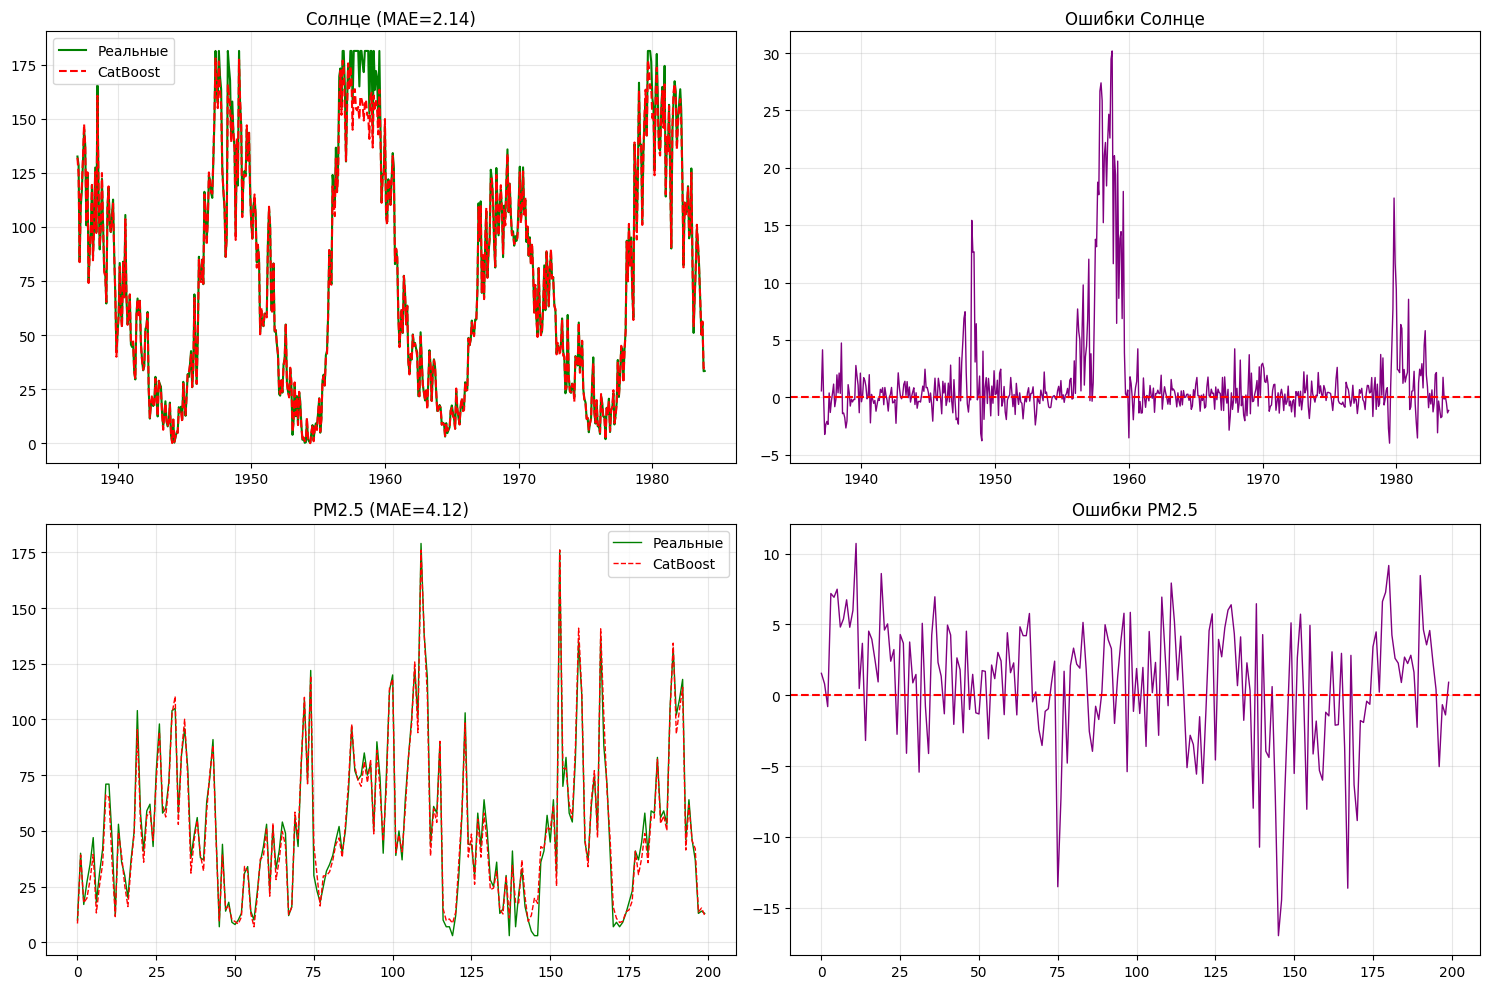

In [131]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
dates_sun = df_sun_test['Month'].values
axes[0,0].plot(dates_sun, true_sun, 'g-', lw=1.5, label='Реальные')
axes[0,0].plot(dates_sun, pred_sun, 'r--', lw=1.5, label='CatBoost')
axes[0,0].set_title(f'Солнце (MAE={mae_sun:.2f})')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

errors_sun = true_sun - pred_sun
axes[0,1].plot(dates_sun, errors_sun, 'purple', lw=1)
axes[0,1].axhline(0, color='red', linestyle='--')
axes[0,1].set_title('Ошибки Солнце'); axes[0,1].grid(True, alpha=0.3)

n_show = min(200, len(true_pol))
axes[1,0].plot(true_pol[:n_show], 'g-', lw=1, label='Реальные')
axes[1,0].plot(pred_pol[:n_show], 'r--', lw=1, label='CatBoost')
axes[1,0].set_title(f'PM2.5 (MAE={mae_pol:.2f})')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

errors_pol = true_pol - pred_pol
axes[1,1].plot(errors_pol[:n_show], 'purple', lw=1)
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_title('Ошибки PM2.5'); axes[1,1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [132]:
train_sun_nf = pd.DataFrame({'unique_id':'sunspots','ds':df_sun_train['Month'],'y':df_sun_train['sunspots_clipped']})
test_sun_nf  = pd.DataFrame({'unique_id':'sunspots','ds':df_sun_test['Month'],'y':df_sun_test['sunspots_clipped']})

hist_exog_pol = raw_exog
train_pol_nf = df_pollution_train[['datetime'] + [target_col] + hist_exog_pol + futr_exog_pol].copy()
train_pol_nf.rename(columns={'datetime':'ds', target_col:'y'}, inplace=True)
train_pol_nf['unique_id'] = 'pollution'

test_pol_nf = df_pollution_test[['datetime'] + [target_col] + hist_exog_pol + futr_exog_pol].copy()
test_pol_nf.rename(columns={'datetime':'ds', target_col:'y'}, inplace=True)
test_pol_nf['unique_id'] = 'pollution'

horizon_sun = min(24, len(test_sun_nf))
horizon_pol = min(48, len(test_pol_nf))
input_sun = min(60, len(train_sun_nf)-horizon_sun)
input_pol = min(60, len(train_pol_nf)-horizon_pol)
print(f"Солнце: input={input_sun}, horizon={horizon_sun}")
print(f"Pollution: input={input_pol}, horizon={horizon_pol}")

Солнце: input=60, horizon=24
Pollution: input=60, horizon=48


In [133]:
models_sun = [
    DeepAR(input_size=input_sun, h=horizon_sun, max_steps=500, logger=False, enable_progress_bar=False),
    NBEATS(input_size=input_sun, h=horizon_sun, max_steps=500, logger=False, enable_progress_bar=False),
    TCN(input_size=input_sun, h=horizon_sun, max_steps=500, logger=False, enable_progress_bar=False)
]
nf_sun = NeuralForecast(models=models_sun, freq='MS')
nf_sun.fit(df=train_sun_nf)
forecasts_sun = nf_sun.predict()
true_sun_nf = test_sun_nf['y'].values[:horizon_sun]
preds_sun = {
    'DeepAR': forecasts_sun['DeepAR'].values[-horizon_sun:],
    'NBEATS': forecasts_sun['NBEATS'].values[-horizon_sun:],
    'TCN': forecasts_sun['TCN'].values[-horizon_sun:]
}
metrics_sun = {name: {'MAE': mean_absolute_error(true_sun_nf, p),
                      'RMSE': np.sqrt(mean_squared_error(true_sun_nf, p))}
               for name, p in preds_sun.items()}
for name, m in metrics_sun.items():
    print(f"Солнце {name}: MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}")

Seed set to 1
Seed set to 1
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type             | Params | Mode 
----------------------------------------------------------
0 | loss         | DistributionLoss | 5      | train
1 | valid_loss   | MAE              | 0      | train
2 | padder_train | ConstantPad1d    | 0      | train
3 | scaler       | TemporalNorm     | 0      | train
4 | hist_encoder | LSTM             | 199 K  | train
5 | decoder      | MLP              | 387    | train
----------------------------------------------------------
199 K     Trainable params
5         Non-trainable params
199 K     Total params
0.798     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISI

Солнце DeepAR: MAE=87.21, RMSE=89.81
Солнце NBEATS: MAE=23.91, RMSE=30.54
Солнце TCN: MAE=35.39, RMSE=42.29


In [134]:
models_pol = [
    DeepAR(input_size=input_pol, h=horizon_pol, max_steps=500,
           futr_exog_list=futr_exog_pol,
           logger=False, enable_progress_bar=False),
    NBEATS(input_size=input_pol, h=horizon_pol, max_steps=500,
           logger=False, enable_progress_bar=False),
    TCN(input_size=input_pol, h=horizon_pol, max_steps=500,
        hist_exog_list=hist_exog_pol,
        logger=False, enable_progress_bar=False)
]
nf_pol = NeuralForecast(models=models_pol, freq='6H')
nf_pol.fit(df=train_pol_nf)

futr_pol = test_pol_nf[['unique_id','ds'] + futr_exog_pol].iloc[:horizon_pol]
forecasts_pol = nf_pol.predict(futr_df=futr_pol)

true_pol_nf = test_pol_nf['y'].values[:horizon_pol]
preds_pol = {
    'DeepAR': forecasts_pol['DeepAR'].values[-horizon_pol:],
    'NBEATS': forecasts_pol['NBEATS'].values[-horizon_pol:],
    'TCN': forecasts_pol['TCN'].values[-horizon_pol:]
}
metrics_pol = {name: {'MAE': mean_absolute_error(true_pol_nf, p),
                      'RMSE': np.sqrt(mean_squared_error(true_pol_nf, p))}
               for name, p in preds_pol.items()}
for name, m in metrics_pol.items():
    print(f"PM2.5 {name}: MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}")

Seed set to 1
Seed set to 1
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type             | Params | Mode 
----------------------------------------------------------
0 | loss         | DistributionLoss | 5      | train
1 | valid_loss   | MAE              | 0      | train
2 | padder_train | ConstantPad1d    | 0      | train
3 | scaler       | TemporalNorm     | 0      | train
4 | hist_encoder | LSTM             | 201 K  | train
5 | decoder      | MLP              | 387    | train
----------------------------------------------------------
202 K     Trainable params
5         Non-trainable params
202 K     Total params
0.808     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISI

PM2.5 DeepAR: MAE=29.19, RMSE=36.26
PM2.5 NBEATS: MAE=53.66, RMSE=68.60
PM2.5 TCN: MAE=47.37, RMSE=55.63


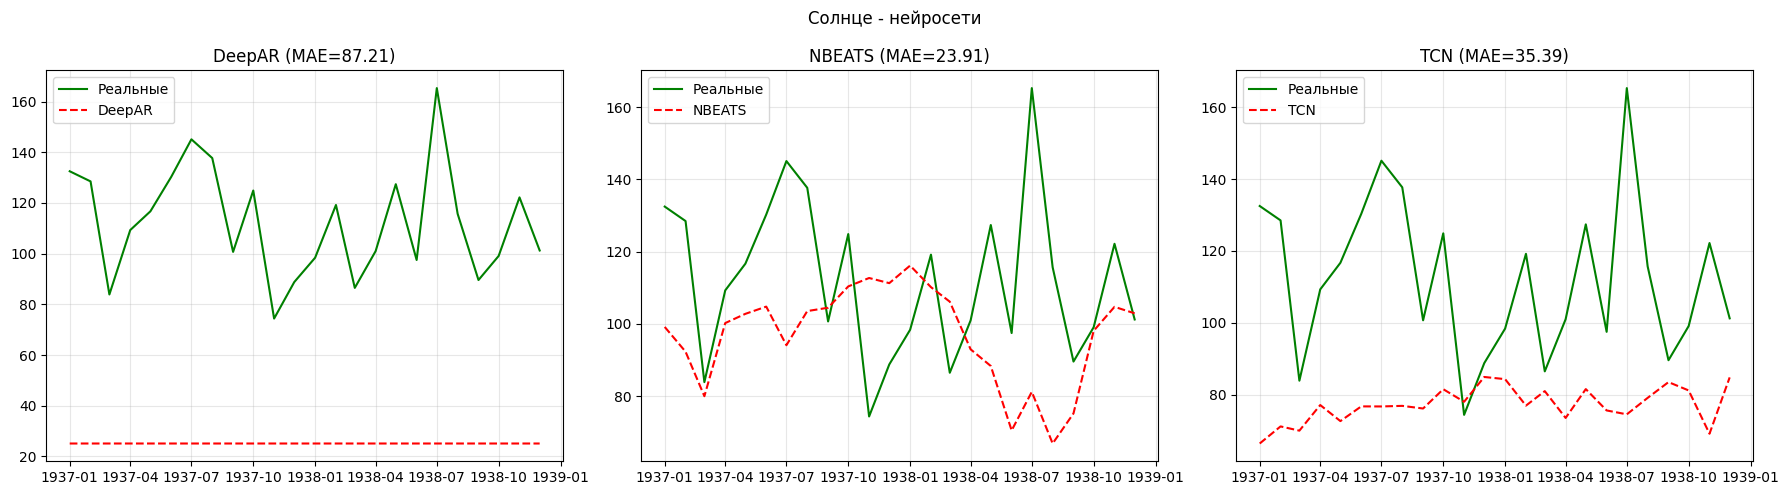

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dates_sun_nf = test_sun_nf['ds'].values[:horizon_sun]
for ax, (name, pred) in zip(axes, preds_sun.items()):
    ax.plot(dates_sun_nf, true_sun_nf, 'g-', lw=1.5, label='Реальные')
    ax.plot(dates_sun_nf, pred, 'r--', lw=1.5, label=name)
    ax.set_title(f'{name} (MAE={metrics_sun[name]["MAE"]:.2f})')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Солнце - нейросети')
plt.tight_layout(); plt.show()

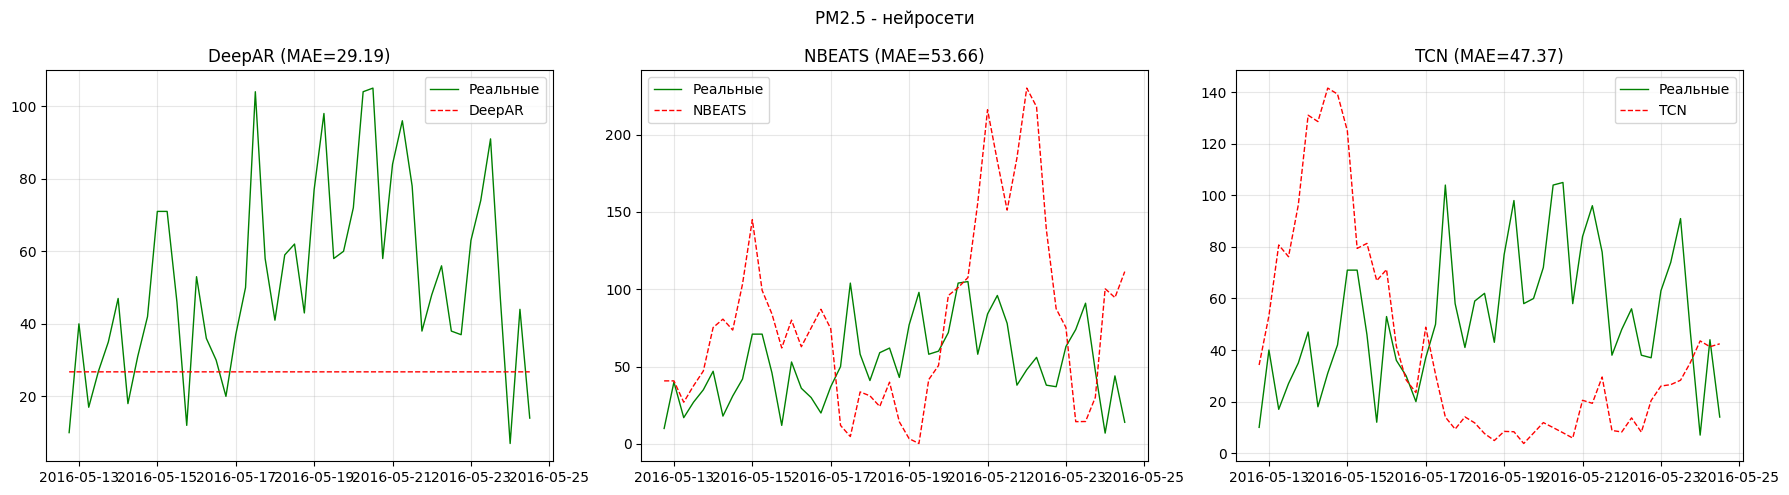

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dates_pol_nf = test_pol_nf['ds'].values[:horizon_pol]
for ax, (name, pred) in zip(axes, preds_pol.items()):
    ax.plot(dates_pol_nf, true_pol_nf, 'g-', lw=1, label='Реальные')
    ax.plot(dates_pol_nf, pred, 'r--', lw=1, label=name)
    ax.set_title(f'{name} (MAE={metrics_pol[name]["MAE"]:.2f})')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('PM2.5 - нейросети')
plt.tight_layout(); plt.show()

In [137]:
comparison = pd.DataFrame({
    'Модель': ['CatBoost', 'DeepAR', 'NBEATS', 'TCN'],
    'Солнце MAE': [mae_sun, metrics_sun['DeepAR']['MAE'], metrics_sun['NBEATS']['MAE'], metrics_sun['TCN']['MAE']],
    'Солнце RMSE': [rmse_sun, metrics_sun['DeepAR']['RMSE'], metrics_sun['NBEATS']['RMSE'], metrics_sun['TCN']['RMSE']],
    'PM2.5 MAE': [mae_pol, metrics_pol['DeepAR']['MAE'], metrics_pol['NBEATS']['MAE'], metrics_pol['TCN']['MAE']],
    'PM2.5 RMSE': [rmse_pol, metrics_pol['DeepAR']['RMSE'], metrics_pol['NBEATS']['RMSE'], metrics_pol['TCN']['RMSE']]
})
display(comparison)

,Модель,Солнце MAE,Солнце RMSE,PM2.5 MAE,PM2.5 RMSE
0,CatBoost,2.141234,4.855294,4.116504,7.331870
1,DeepAR,87.211637,89.811073,29.191036,36.258838
2,NBEATS,23.911234,30.540074,53.661456,68.600746
3,TCN,35.389640,42.291338,47.371823,55.626486


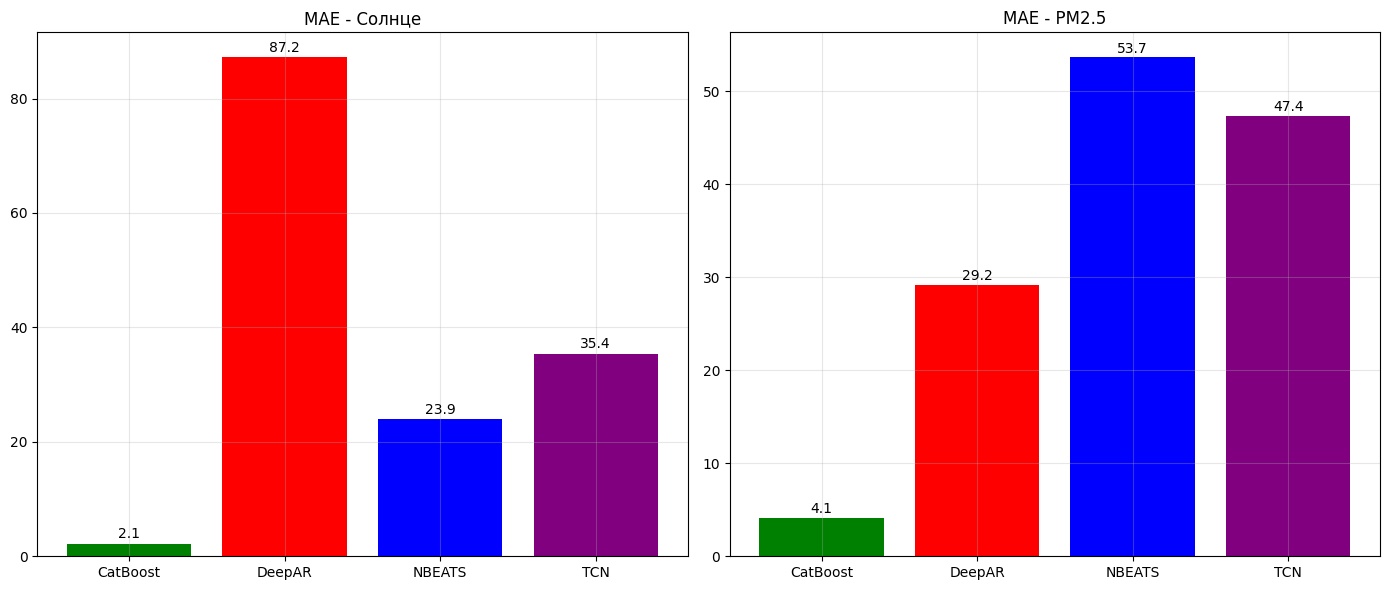

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models_names = ['CatBoost','DeepAR','NBEATS','TCN']
sun_mae_vals = [mae_sun, metrics_sun['DeepAR']['MAE'], metrics_sun['NBEATS']['MAE'], metrics_sun['TCN']['MAE']]
pm_mae_vals  = [mae_pol, metrics_pol['DeepAR']['MAE'], metrics_pol['NBEATS']['MAE'], metrics_pol['TCN']['MAE']]

bars1 = axes[0].bar(models_names, sun_mae_vals, color=['green','red','blue','purple'])
axes[0].set_title('MAE - Солнце'); axes[0].grid(True, alpha=0.3)
for bar, val in zip(bars1, sun_mae_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}', ha='center')

bars2 = axes[1].bar(models_names, pm_mae_vals, color=['green','red','blue','purple'])
axes[1].set_title('MAE - PM2.5'); axes[1].grid(True, alpha=0.3)
for bar, val in zip(bars2, pm_mae_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}', ha='center')

plt.tight_layout(); plt.show()